## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon, resize
from scipy.ndimage import zoom

## Loading and Visualizing Data

In [3]:
# loading in data from the relative folder
ct_sino = np.load("module1/ct_sinogram.npy") # as measured, i.e. transmission sinogram
ct_dark = np.load("module1/ct_dark.npy")
ct_flat = np.load("module1/ct_flat.npy")
pet_sino = np.load("module1/pet_sinogram.npy") 
pet_calibration = np.load("module1/pet_calibration.npy")

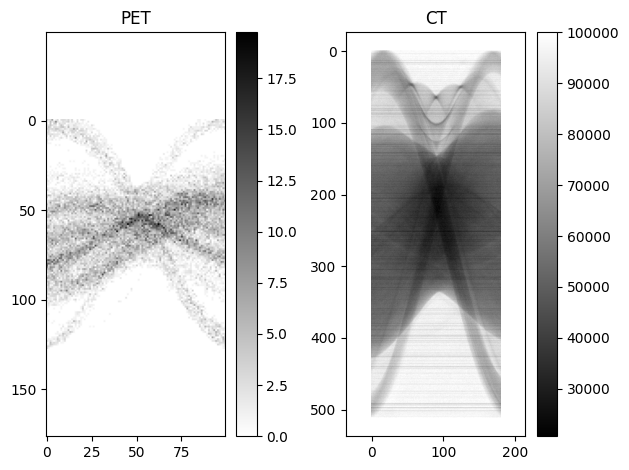

In [4]:
# Display sinograms
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(pet_sino, cmap="gray_r") # PET scientist like to reverse the colorbar 
plt.axis("equal")
plt.colorbar()
plt.title("PET")

plt.subplot(1, 2, 2)
plt.imshow(ct_sino, cmap="gray")
plt.colorbar()
plt.axis("equal")
plt.title("CT")

plt.tight_layout()

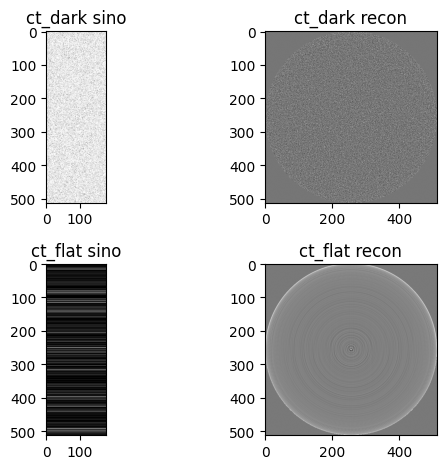

In [5]:
# looking at what ct_flat and ct_dark are
theta = np.linspace(0, 180, 180, endpoint=False) #180 degrees, 1 measurement per degree

plt.subplot(2, 2, 1)
plt.imshow(ct_dark,cmap="gray_r")
plt.title("ct_dark sino")

plt.subplot(2, 2, 2)
plt.imshow(iradon(ct_dark, theta=theta), cmap="gray")
plt.title("ct_dark recon")

plt.subplot(2, 2, 3)
plt.imshow(ct_flat,cmap="gray_r")
plt.title("ct_flat sino")

plt.subplot(2, 2, 4)
plt.imshow(iradon(ct_flat, theta=theta), cmap="gray")
plt.title("ct_flat recon")

plt.tight_layout()

## Understanding Data

In [6]:
print("Sinogram") 
print(ct_sino.shape) #b in Ax=b
print(ct_sino.max())
print(ct_sino.min())

print("Flat")
print(ct_flat.shape)
print(ct_flat.max())
print(ct_flat.min())

print("Dark")
print(ct_dark.shape)
print(ct_dark.max())
print(ct_dark.min())

print("PET")
print(pet_sino.shape)
print(pet_sino.max())
print(pet_sino.min())

print("PET calibration")
print(pet_calibration.shape)
print(pet_calibration.max())
print(pet_calibration.min())

Sinogram
(512, 180)
100000.0
20677.55418267033
Flat
(512, 180)
100000.0
83713.53816144787
Dark
(512, 180)
3993.025387937246
0.0
PET
(128, 100)
19.74697075716186
0.0
PET calibration
(128, 100)
1.3772451076428047
0.6435323228379088


## Cleaning up sinograms before reconstruction

In [7]:
# Subtract ct_dark to clean up noise, divide by cleaned I0 to normalize
ct_sino_clean = (ct_sino - ct_dark) / (ct_flat - ct_dark)

# replace NaN by 0 to 'avoid' division by 0
ct_sino_clean = np.where((ct_flat - ct_dark) == 0, 0, ct_sino_clean)

# normalize the pet sinogram
pet_sino_clean = pet_sino / pet_calibration

# replace NaN by 0 to 'avoid' division by 0
pet_sino_clean = np.where(pet_calibration == 0, 0, pet_sino_clean)

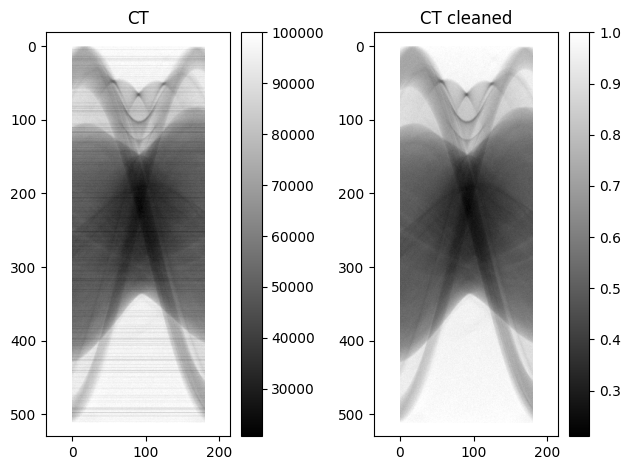

In [8]:
# Display CT sinograms
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(ct_sino, cmap="gray")
plt.axis("equal")
plt.colorbar()
plt.title("CT")

plt.subplot(1, 2, 2)
plt.imshow(ct_sino_clean, cmap="gray")
plt.colorbar()
plt.axis("equal")
plt.title("CT cleaned")

plt.tight_layout()

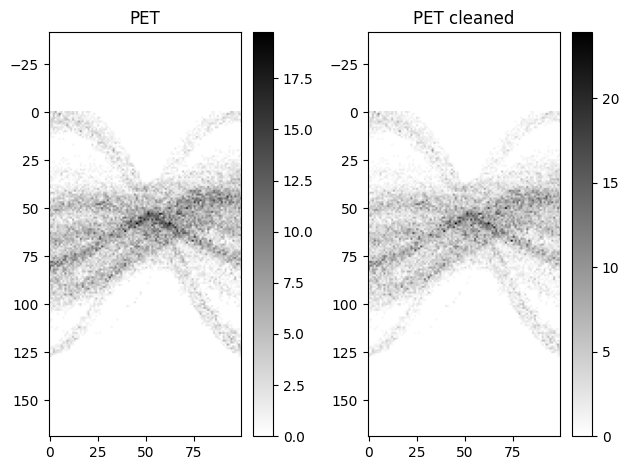

In [9]:
# Display PET sinograms
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(pet_sino, cmap="gray_r")
plt.axis("equal")
plt.colorbar()
plt.title("PET")

plt.subplot(1, 2, 2)
plt.imshow(pet_sino_clean, cmap="gray_r")
plt.colorbar()
plt.axis("equal")
plt.title("PET cleaned")

plt.tight_layout()

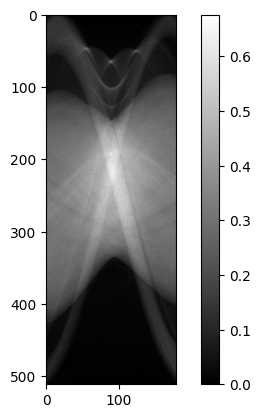

In [10]:
ct_sino_clean_absorp = -np.log10(ct_sino_clean)
plt.imshow(ct_sino_clean_absorp, cmap='grey')
plt.colorbar()

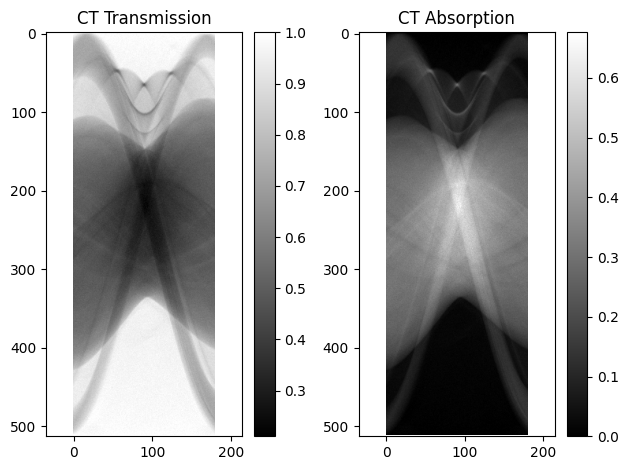

In [19]:
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(ct_sino_clean, cmap="gray")
plt.axis("equal")
plt.colorbar()
plt.title("CT Transmission")

plt.subplot(1, 2, 2)
plt.imshow(ct_sino_clean_absorp, cmap="gray")
plt.colorbar()
plt.axis("equal")
plt.title("CT Absorption")

plt.tight_layout()

## Reconstruction

(512, 512)


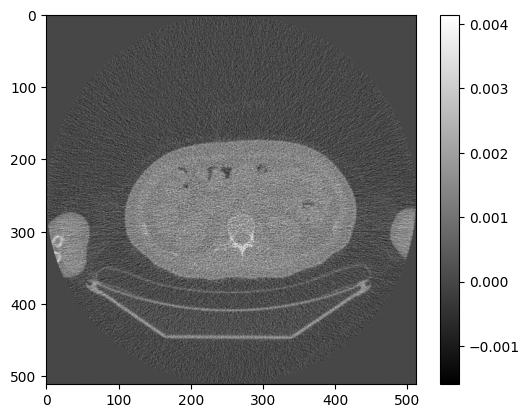

In [11]:
# Reconstruct the CT image with FBP
theta = np.linspace(0, 180, 180, endpoint=False) #180degrees, 1 measurement per degree
ct_sino_clean_absorp = -np.log10(ct_sino_clean)
fbp_recon_ct = iradon(ct_sino_clean_absorp, theta=theta)
plt.imshow(fbp_recon_ct, cmap='grey')
plt.colorbar()
print(fbp_recon_ct.shape)

In [12]:
def total_variation(image):
    """
    Calculate the total variation of the image.

    This function calculates the total variation form of the image, defined as 
    the sum of the derivatives (absolute differences) between adjacent pixel.  
    It captures the image's "smoothness".

    Parameters:
    image: ndarray
        an image to be applied to.

    Returns:
    float: a Total Variation (TV) norm of the image.

    Example:
    >>> tv_fbp = total_variation(fbp_recon_ct)
    """
    tv = np.sum(np.sqrt(np.diff(image, axis=0, append=0)**2 + np.diff(image, axis=1, append=0)**2))
    return tv

In [13]:
#Computing TV for FBP reconstructed image
tv_fbp = total_variation(fbp_recon_ct)
print("FBP reconstruction TV-norm is:", tv_fbp)
print("FBP reconstruction L1-norm is:",np.linalg.norm(fbp_recon_ct, ord=1))
print("FBP reconstruction L2-norm is:",np.linalg.norm(fbp_recon_ct, ord=2))

FBP reconstruction TV-norm is: 128.72932195170046
FBP reconstruction L1-norm is: 0.42208321227467616
FBP reconstruction L2-norm is: 0.32954592675439137


In [14]:
def os_sart_reconstruction(K, gamma_list, num_parts, ct_sino_clean_absorp):
    """
    Perform OS-SART for CT image reconstruction.

    This function implements the OS-SART algorithm, iteratively reconstructing a CT image 
    using a cleaned absorption sinogram.

    Parameters:
    K: int
        The number of iterations to perform for the reconstruction process.
    
    gamma_list: list of float
        A list of step sizes to test during the reconstruction.

    num_parts: int
        The number of subsets into which the full dataset is divided.

    ct_sino_clean_absorp: ndarray
        The cleaned absorption CT sinogram. This is used to compute residuals during the reconstruction.

    Returns:
    ndarray
        The reconstructed CT image after applying the OS-SART algorithm for the last gama value,
        The function also visualizes the results of the reconstruction for all gamma values used. 
        It displays the reconstructed images and their corresponding Total Variation (TV) norms.

    Example:
    >>> os_sart_recon_image = os_sart_reconstruction(K=50, gamma_list=[-1e-3, -1e-4, -1e-5], num_parts=10, ct_sino_clean_absorp=ct_sino_clean_absorp)
    """
    #determine number of angles in a part
    num_angles = 180 // num_parts
    # Set the figure size
    plt.figure(figsize=(len(gamma_list) * 5, len(gamma_list) * 10)) 
    for g in range(len(gamma_list)):
        x_os_sart = np.zeros((512, 512)) # iradon(ct_sino, theta=theta).shape
        for k in range(K): #𝑥_𝑘+1 = 𝑥_𝑘 + 𝛾 ∗ 𝐴𝑇𝑖 (A𝑖𝑥^𝑘 − 𝑏)
            for i in range(num_parts):
                theta_i = np.linspace(i*num_angles, (i+1)*num_angles, num_angles, endpoint=False)
                f_proj = radon(x_os_sart, theta=theta_i)
                # slicing corresponding sinogram subset for proper broadcasting
                ct_sino_subset = ct_sino_clean_absorp[:, i * num_angles : (i + 1) * num_angles]
                residual = f_proj - ct_sino_subset
                x_os_sart = x_os_sart + gamma_list[g] * iradon(residual, theta=theta_i, filter_name=None)
        print(f"for gamma={gamma_list[g]}, TV norm is:", total_variation(x_os_sart))
        plt.subplot(len(gamma_list), 2, g+1)
        plt.imshow(x_os_sart, cmap="grey")
        plt.title(f"gamma={gamma_list[g]}")
        plt.colorbar()
    plt.tight_layout()
    return x_os_sart

In [15]:
# Reconstruct the CT image with OS-SART (basically, stochastic GD)
K = 50 #number of iterations
gamma_list = [-1e-3, -5e-4, -1e-4, -1e-5]
num_parts = 10 # number of equally sized parts
x_os_sart = os_sart_reconstruction(K, gamma_list, num_parts, ct_sino_clean_absorp)

KeyboardInterrupt: 

<Figure size 2000x4000 with 0 Axes>

In [ ]:
# Finding K for gamma=-0.001 that outperforms FBP
K = 1000 #number of iterations
gamma_list = [-1e-3]
num_parts = 10 # number of equally sized parts
num_angles = 180 // num_parts

# Set the figure size
plt.figure(figsize=(len(gamma_list) * 5, len(gamma_list) * 10)) 

for g in range(len(gamma_list)):
    x_os_sart = np.zeros((512, 512)) # iradon(ct_sino, theta=theta).shape
    x_os_sart_prev = np.zeros((512, 512))
    for k in range(K): #𝑥_𝑘+1 = 𝑥_𝑘 + 𝛾 ∗ 𝐴𝑇𝑖 (A𝑖𝑥^𝑘 − 𝑏)
        for i in range(num_parts):
            theta_i = np.linspace(i*num_angles, (i+1)*num_angles, num_angles, endpoint=False)
            f_proj = radon(x_os_sart, theta=theta_i)
            # slicing corresponding sinogram subset for proper broadcasting
            ct_sino_subset = ct_sino_clean_absorp[:, i * num_angles : (i + 1) * num_angles]
            residual = f_proj - ct_sino_subset
            x_os_sart = x_os_sart + gamma_list[g] * iradon(residual, theta=theta_i, filter_name=None)
        if np.allclose(total_variation(x_os_sart), total_variation(x_os_sart_prev), atol=0.1):
            print(f"TV not changing much at iteration: {k}")
            break
        else:
            x_os_sart_prev = x_os_sart
    print(f"for gamma={gamma_list[g]}, TV norm is:", total_variation(x_os_sart))

TV not changing much at iteration: 176
for gamma=-0.001, TV norm is: 94.50291450987143


<Figure size 500x1000 with 0 Axes>

In [ ]:
#Computing TV for OS-SART reconstructed image
tv_os_sart = total_variation(x_os_sart)
print("FBP reconstruction TV-norm is:", tv_os_sart)
print("FBP reconstruction L1-norm is:",np.linalg.norm(x_os_sart, ord=1))
print("FBP reconstruction L2-norm is:",np.linalg.norm(x_os_sart, ord=2))

FBP reconstruction TV-norm is: 94.50291450987143
FBP reconstruction L1-norm is: 0.39269328956348376
FBP reconstruction L2-norm is: 0.32915489551824156


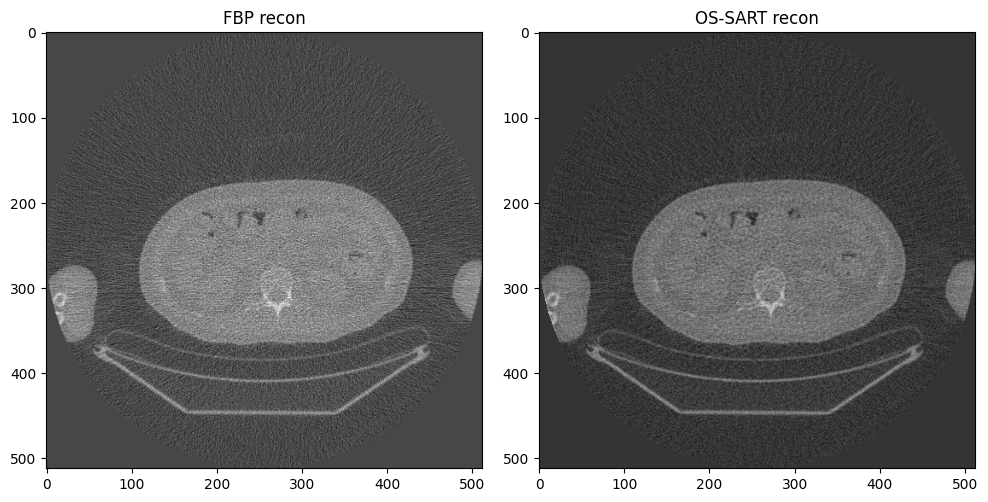

In [ ]:
# comparing FBP and OS-SART reconstructions
plt.figure(figsize=(10,20)) 

plt.subplot(1,2,1)
plt.imshow((fbp_recon_ct), cmap='grey')
#plt.colorbar()
plt.title("FBP recon")

plt.subplot(1,2,2)
plt.imshow(x_os_sart, cmap='grey')
#plt.colorbar()
plt.title("OS-SART recon")

plt.tight_layout()

Extra: How does it to compare to SIRT (i.e. gradient descent as we did in the CT practical)? Does it reach a good result faster or slower? Does it need more or less iterations?



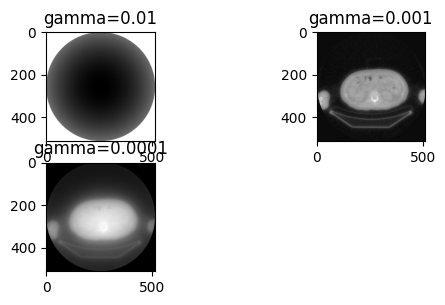

In [ ]:
# Reconstruct the CT image with SIRT (GD) for comparison
K = 50
theta = np.linspace(0, 180, 180, endpoint=False)
gamma_list = [1e-2,1e-3, 1e-4]
for g in range(len(gamma_list)):
    x_sirt = np.zeros((512,512))
    for i in range(K):
        x_sirt = x_sirt - gamma_list[g] * iradon(radon(x_sirt, theta=theta) - ct_sino_clean_absorp, theta=theta, filter_name=None)
    plt.subplot(len(gamma_list),2,g+1)
    plt.imshow(x_sirt, cmap="grey")
    plt.title(f"gamma={gamma_list[g]}")

## CT image resizing

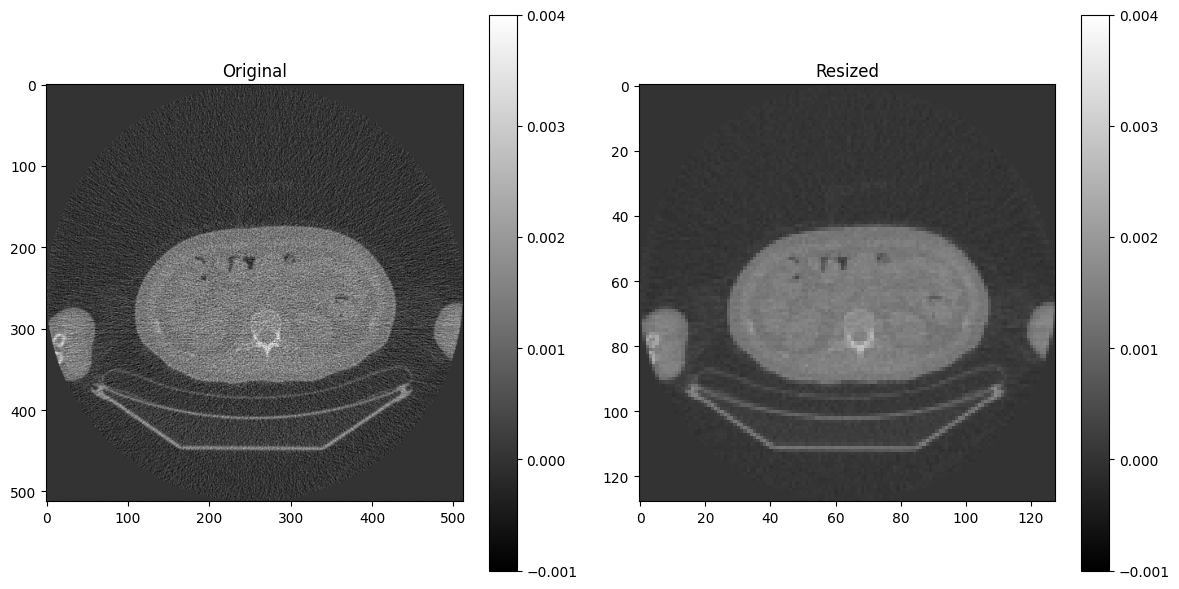

In [ ]:
# change size of CT image to match size of PET
# Calculate the re-sizing factor
factors = (pet_sino.shape[0] / fbp_recon_ct.shape[0], pet_sino.shape[0] / fbp_recon_ct.shape[1])

# Resize the CT image to match the size of PET image
# resized_recon_ct = zoom(fbp_recon_ct, factors)
new_dimensions = (int(fbp_recon_ct.shape[0] * factors[0]), int(fbp_recon_ct.shape[1] * factors[1]))
resized_ct_image = resize(fbp_recon_ct, new_dimensions, anti_aliasing=True)

# visualize resized image next to original
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(fbp_recon_ct, cmap="grey")
plt.title("Original")
plt.clim(-0.001,0.004)
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(resized_ct_image, cmap="grey")
plt.title("Resized")
plt.clim(-0.001,0.004)
plt.colorbar()

plt.tight_layout()

/Users/ilyakogan/Desktop/venvs/a2coursework/lib/python3.13/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


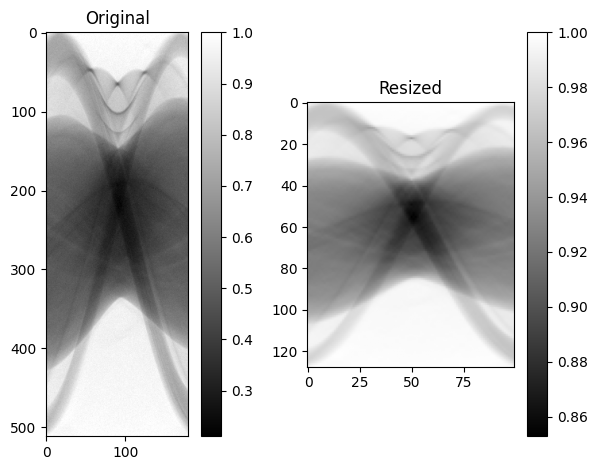

In [ ]:
# producing sinogram of resized image
theta1 = np.linspace(0.0, 180.0, 100, endpoint=False)
resized_sino = radon(resized_ct_image, theta=theta1)

# visualize resized sinogram next to original
plt.subplot(1,2,1)
plt.imshow(ct_sino_clean, cmap="grey")
plt.title("Original")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(np.exp(-resized_sino), cmap="grey")
plt.title("Resized")
plt.colorbar()

plt.tight_layout()

Text(0.5, 1.0, 'Corrected for attenuation')

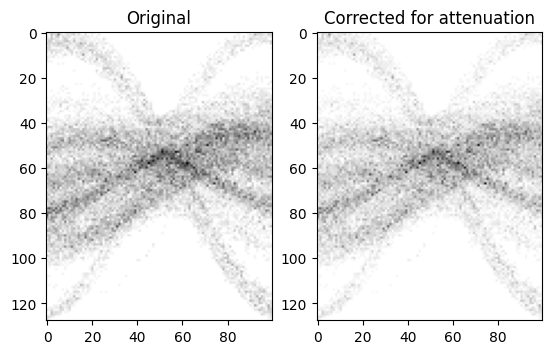

In [ ]:
# Attenuation correction for PET
I_em_pet = pet_sino_clean / np.exp(-resized_sino)

# visualization of raw PET and corrected for attenuation
plt.subplot(1,2,1)
plt.imshow(pet_sino, cmap="grey_r")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(I_em_pet, cmap="grey_r")
plt.title("Corrected for attenuation")

In [20]:
#-np.log10(ct_sino_clean)

(128, 128)


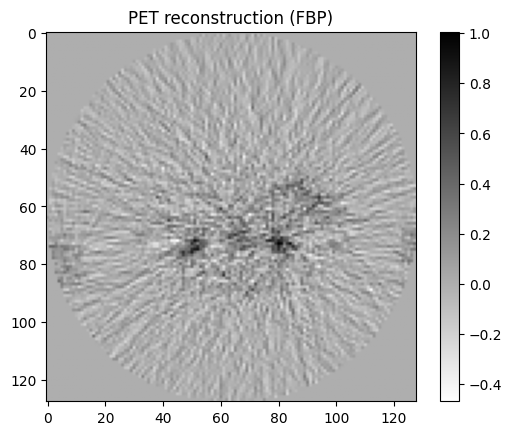

In [ ]:
# reconstructing PET image with FBP
recon_pet = iradon(I_em_pet, theta=theta1)

# visualizing reconstructed PET
plt.imshow(recon_pet, cmap="grey_r")
plt.title("PET reconstruction (FBP)")
plt.colorbar()
print(recon_pet.shape)


In [ ]:
# checking the corrected for attenuation sinogram
I_em_pet

array([[4.05907542, 2.21432148, 2.37046418, ..., 1.63379129, 2.10672752,
        1.3052863 ],
       [1.0744499 , 0.70576115, 5.00050215, ..., 0.61692757, 3.98216524,
        2.51205914],
       [1.66334493, 0.        , 5.54503419, ..., 1.76323983, 0.9797505 ,
        2.11330587],
       ...,
       [0.        , 0.71260239, 4.25706391, ..., 0.84854287, 0.99349465,
        2.72390013],
       [2.66853379, 3.42597889, 1.82232703, ..., 0.        , 1.30805367,
        1.85369916],
       [3.10164788, 0.83786646, 0.        , ..., 0.        , 0.79882566,
        1.02692821]], shape=(128, 100))

In [ ]:
def osem_reconstruction(K, num_parts, I_em_pet):
    """
    Perform OSEM reconstruction for PET images.

    This function applies the OSEM algorithm to reconstruct an image
    from the provided emission data using a specified number of iterations
    and subsets.

    Parameters:
    K: int
    The number of iterations to perform in the reconstruction process.
    
    num_parts: int
    The number of subsets to divide the angles into.
        
    I_em_pet: np.ndarray 
    The sinogram data (2D array) representing the measured emission data corresponding to each angle.

    Returns:
    np.ndarray: The reconstructed PET image as a 2D array.
    
    Example:
        recon_image = osem_reconstruction(K=1, num_parts=10, I_em_pet=I_em_pet)
    """
    parts_angles = 180 // num_parts #18 degrees per part
    num_angles = 100 // num_parts #10 angles per part
    recon_pet_osem = np.ones(recon_pet.shape) #ones because of multiplication

    for k in range(K):
        # inner loop, processing subsets
        for i in range(num_parts):
            theta_i = np.linspace(i*parts_angles, (i+1)*parts_angles, num_angles, endpoint=False)
            f_proj = radon(recon_pet_osem, theta=theta_i) # forward projection of current image
            # slicing corresponding sinogram for proper broadcasting
            I_em_pet_i = I_em_pet[:, i * num_angles : (i + 1) * num_angles]
            # Calculate the ratio to avoid division by zero
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = I_em_pet_i / f_proj
                ratio[np.isnan(ratio)] = 0
                ratio[np.isinf(ratio)] = 0  # Handling division by near zero
            recon_pet_osem = recon_pet_osem * iradon(ratio, theta=theta_i, filter_name=None) # backprojection

    # visualizing reconstructed pet
    plt.imshow(recon_pet_osem, cmap="grey_r")
    plt.title("OSEM PET reconstruction")
    plt.colorbar()
    return recon_pet_osem

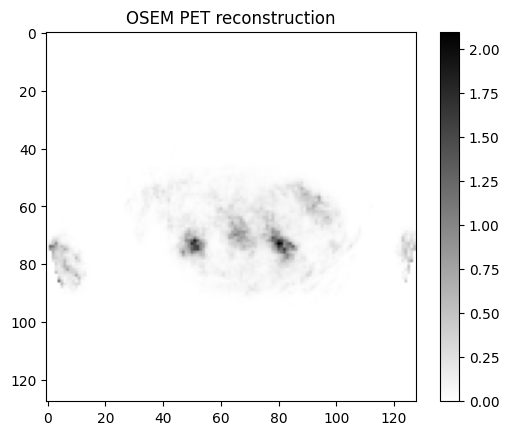

In [ ]:
# reconstructing PET image with OSEM
K = 1
num_parts = 10
recon_pet_osem = osem_reconstruction(K, num_parts, I_em_pet)

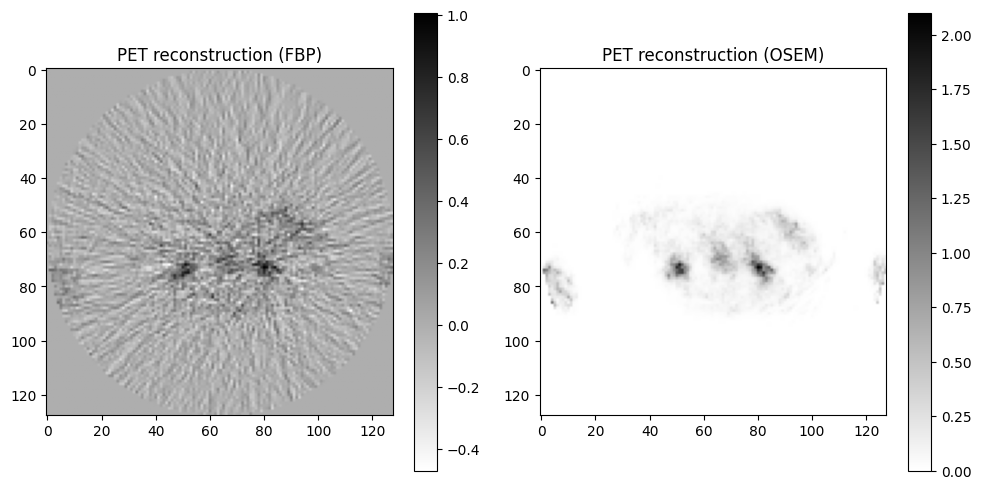

In [ ]:
# visualizing reconstructed PETs side by side
plt.figure(figsize=(10,5)) 

plt.subplot(1,2,1)
plt.imshow(recon_pet, cmap="grey_r")
plt.title("PET reconstruction (FBP)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(recon_pet_osem, cmap="grey_r")
plt.title("PET reconstruction (OSEM)")
plt.colorbar()
plt.tight_layout()

Text(0.5, 1.0, 'MLEM reconstruction')

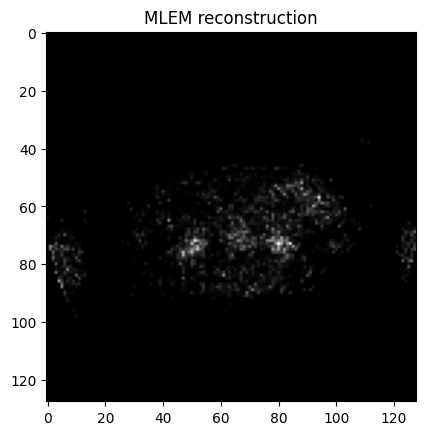

In [ ]:
# OSEM vs MLEM

# reconstructing PET image with MLEM
recon_pet_mlem = np.ones(recon_pet.shape)
N = 50

for i in range(N):
    f_proj = radon(recon_pet_mlem, theta=theta1) # forward projection of current image

    # to avoid division by 0
    with np.errstate(divide='ignore', invalid='ignore'):
        diff = pet_sino / f_proj # ratio of target to current
        diff[np.isnan(diff)] = 0  # Set NaN values to 0

    recon_pet_mlem = recon_pet_mlem * iradon(diff, theta=theta1, filter_name=None) # correction step (involves backprojection)

# visualizing reconstructed pet
plt.imshow(recon_pet_mlem, cmap="grey")
plt.title("MLEM reconstruction")

## Theoretical Questions

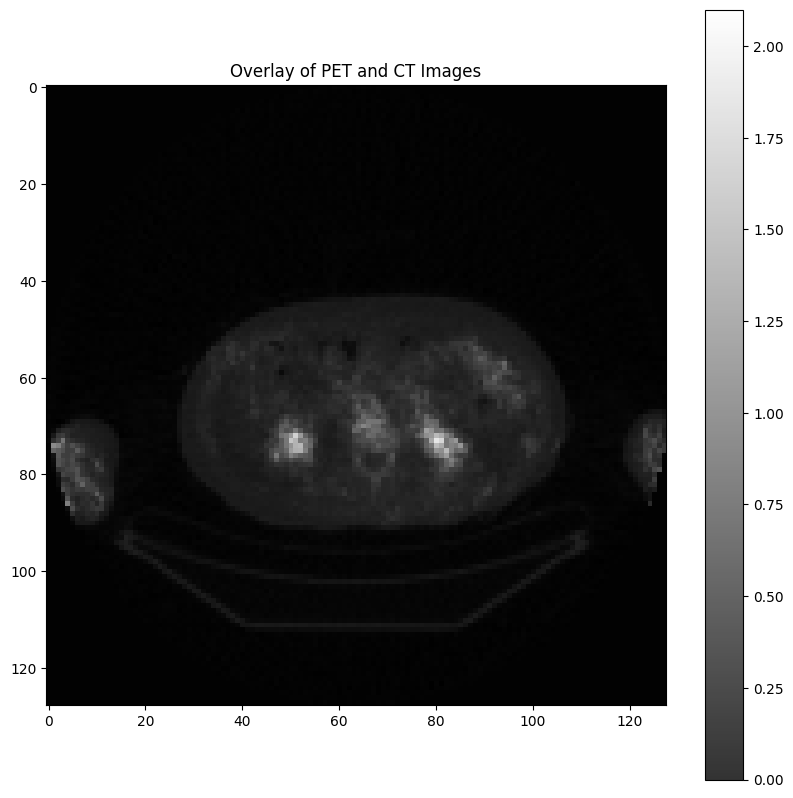

In [ ]:
# Create a figure
plt.figure(figsize=(10, 10))

# Display CT
plt.imshow(resized_ct_image, cmap='gray')

# Overlay PET
plt.imshow(recon_pet_osem, cmap='gray', alpha=0.8)

plt.title("Overlay of PET and CT Images")
plt.colorbar()
plt.show()

Q: If we had a TOF-PET scanner, how accurate would we need to be at
measuring time to know the location of the emission so precisely that
reconstruction would not be needed?

A: If we had a TOF-PET (Time-of-Flight PET) scanner, we would need to measure time in nanoseconds to know the location of the emission so precisely that the 
reconstruction would not be needed. The signal that is collected during PET comes from annihilation of positron and an electron, leading to two photons, or X-rays, that travel in opposite directions, at $179.5^\circ$ to be precise. With TOF-PET we want to derive the location of the source of these 2 X-rays, based on the time measurements of opposite detectors. Since we still need CT image for anatomical analysis, let's take the resolution of the given CT image, where 1 pixel is 1.06 mm in size. Thus, we want to be able to determine 1.06mm based on our time measuremnts of detectors. Given that speed of X-ray is equal to speed of light which is $3\times10^8$ m/s, or $3\times10^{11}$ mm/s. To be able to determine 1mm, we need time resolution of $$\frac{1}{3\times10^{11}}s = 0.33\times 10^{-11}s,$$ or 33ns (nanoseconds).



Q: Why is OSEM the most used algorithm in PET, but not in CT? What makes OSEM different (mathematically) to gradient descent?

A: OSEM is the most used algorithm in PET, but not in CT because PET reconstruction is more challenging while CT images are usually less noisy and using OSEM algorithm is, hence, unnecessary. Gradient Descent is an iterative algorithm that updates parameters of a model based on its cost (or loss) function, using its gradient. At each step, the algorithm moves in the direction of negative gradient, aiming to find global minima. While OSEM is also an iterative algorithm, it is an Expectation-Maximisation algorithm. Also, OSEM divides the data into subsets while in traditional GD algorithm the entire dataset is used at each iteration. However, there exist Stochastic, or batch, version of GD which uses subsets of data at each iteration.

PET-MR scanners exist. What is the extra data processing you need to take in a PET-MR that does not exist in a PET-CT? How is it done?

PET-MR combines two different imaging modalities while in a PET-CT combination image modality is the same, allowing for attenuation correction of PET using CT. The additional data processing step in PET-MR involves obtaining these attenuation coefficients. To enable accurate attenuation correction in PET-MR, attenuation maps are calculated using some calibration data that relates specific MRI signal intensities to known attenuation coefficients determined from CT data.